# Get started with `shrecc.NewDatabase`

This is the shortest complete workflow for writing a historical electricity database. Before running it, create a Brightway project containing a basic ecoinvent (3.9 to 3.12) background database.

The output database name is replaced if it already exists. The expanded [analysis notebook](2_shrecc_analysis.ipynb) covers prospective TYNDP databases, multiple years, physical volumes, mapping diagnostics, and other options.

In [1]:
from shrecc import NewDatabase

## Configure

Edit the project, background database, output name, country, year, and timestamp below. A historical year automatically selects Energy Charts as the source.

In [2]:
# My parameters

years        = 2025 # Either an int or a list
countries    = ["BE", "DE", "FR", "LU"] # A list of countries
project_name = "SHRECCei311" # The name of my Brightway project, where to write the electricity database
bg_db_name   = "ecoinvent-3.11-cutoff" # The name of the background database with which electricity inventories are linked
my_db_name   = "shrecc_20250615_1200" # The name of my new electricity database
times        = ["2025-06-15 12:00:00"] # A list or range of timestamps

# My NewDatabase object

electricity_database = NewDatabase(
    years=years,
    countries=countries,
    project_name=project_name,
    bg_db_name=bg_db_name,
    my_db_name=my_db_name,
    times=times,
)

## Create

`create()` obtains or loads the source data, solves the interconnected electricity system, maps activities, and prepares the database table. It does not modify Brightway.

In [3]:
electricity_database.create()

C:\Users\Gibon\AppData\Local\Temp\ipykernel_31828\878096693.py:1: UserWarning: Energy Charts activity mapping gaps for 2025 were assigned to source-country high-voltage production mixes. Fallback share by consumer: DE 7.7%, LU 6.9%, BE 6.6%, FR 0.8%. Largest source-technology gaps: NL/Others 5.4%, BE/Others 4.3%, LU/Waste non-renewable 2.3%, BE/Waste non-renewable 2.1%, DE/Waste non-renewable 1.6%. See mapping_report(2025) for the full report.
  electricity_database.create()


NewDatabase(years=[2025], sources={2025:energy_charts})

## Write

`write()` writes the prepared inventory to the configured Brightway project. An existing output database with the same name is replaced.

In [4]:
electricity_database.write()

100%|██████████| 4/4 [00:00<00:00, 28.17it/s]


10:47:25+0200 [info     ] Vacuuming database            


NewDatabase(years=[2025], sources={2025:energy_charts})

In [5]:
electricity_database.written_database_names

{2025: 'shrecc_20250615_1200'}

## Check

In [6]:
import bw2data as bd
import bw2calc as bc
import pandas as pd

In [7]:
bd.projects.set_current(project_name)

In [8]:
method = {"impact_categories":[('ecoinvent-3.11',
  'EF v3.1',
  'climate change',
  'global warming potential (GWP100)')]}

demands = {act["location"]:{act["id"]:1} for act in bd.Database(my_db_name)}

data_objs = bd.get_multilca_data_objs(functional_units=demands, method_config=method)

In [9]:
lca = bc.MultiLCA(
    demands=demands,
    method_config=method,
    data_objs=data_objs
    )

In [10]:
lca.lci()
lca.lcia()

Text(0, 0.5, 'global warming potential (GWP100)')

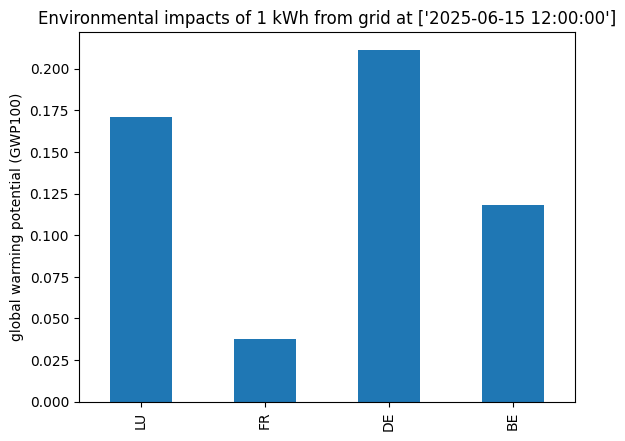

In [11]:
# Show results
ax = pd.DataFrame(lca.scores.items()).plot.bar(legend=None)
ax.set_title(f"Environmental impacts of 1 kWh from grid at {times}")
ax.set_xticklabels(demands.keys())
ax.set_ylabel(method["impact_categories"][0][3])

## Optional: inspect hourly impacts

SHRECC retains the hourly electricity mixes used to build the foreground inventory. `lcia()` calculates their impact intensity per kilowatt hour without writing hourly activities to Brightway. For a longer selected period, the final cell plots the resulting time series.

In [ ]:
hourly_assessment = electricity_database.lcia(
    methods=method["impact_categories"]
)
hourly_assessment

In [ ]:
hourly_intensity = hourly_assessment.hourly(years)["intensity"]
hourly_intensity.sel(
    consumer_country="FR",
    impact_category=hourly_assessment.impact_categories[0],
).plot(marker="o")